<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/practica27_267370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



## Mario Amador - 267370.

###Actividad: Árbol de Decisión para Regresión
### Objetivo
Analizar el comportamiento de un modelo de árbol de decisión en un problema de regresión, evaluando su capacidad de generalización mediante el estudio del sobreajuste, la profundidad del árbol y la poda.

### Dataset
Se utilizará el dataset California Housing, disponible en scikit-learn.



# Instrucciones
## 1. Carga y exploración de datos

* Cargar el dataset en un DataFrame
* Identificar la variable objetivo (MedHouseVal)
* Analizar la estructura del dataset (info, describe)
* Visualizar la distribución de la variable objetivo

In [3]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

In [4]:
# Cargar dataset
california = fetch_california_housing()

# Convertir a DataFrame
df = pd.DataFrame(california.data, columns=california.feature_names)

# Agregar variable objetivo
df["MedHouseVal"] = california.target

# Mostrar primeras filas
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
# Información general
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [6]:
# Estadísticas descriptivas
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

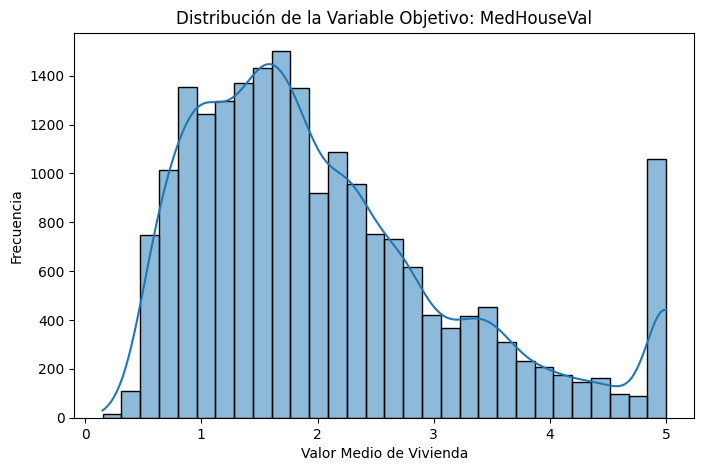

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["MedHouseVal"], bins=30, kde=True)

plt.title("Distribución de la Variable Objetivo: MedHouseVal")
plt.xlabel("Valor Medio de Vivienda")
plt.ylabel("Frecuencia")

plt.show()

En la distribución de la variable objetivo MedHouseVal, se aprecia una asimetría positiva (sesgo hacia la derecha), así como una concentración importante de observaciones en el valor máximo de 5.0, lo que indica una posible limitación superior en la variable objetivo dentro del dataset. Esto puede afectar la capacidad predictiva del modelo en valores altos.

#2. Preparación de datos

* Definir:

  * X: variables predictoras

  * y: variable objetivo

* Dividir los datos en entrenamiento (80%) y prueba (20%)

In [8]:
from sklearn.model_selection import train_test_split

# Definir variables predictoras (X)
X = df.drop("MedHouseVal", axis=1)

# Definir variable objetivo (y)
y = df["MedHouseVal"]

# Dividir datos: 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Mostrar dimensiones de los conjuntos
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (16512, 8)
Dimensiones de X_test: (4128, 8)
Dimensiones de y_train: (16512,)
Dimensiones de y_test: (4128,)


# 3. Modelo base

* Entrenar un árbol de decisión sin restricciones (max_depth=None)

* Evaluar el modelo usando:

  * RMSE

  * R²

* Comparar desempeño en entrenamiento y prueba

* Determinar si existe sobreajuste

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Crear modelo base sin restricciones
modelo_base = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

# Entrenar modelo
modelo_base.fit(X_train, y_train)

# Predicciones en entrenamiento
y_train_pred = modelo_base.predict(X_train)

# Predicciones en prueba
y_test_pred = modelo_base.predict(X_test)

# RMSE entrenamiento
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# RMSE prueba
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# R² entrenamiento
r2_train = r2_score(y_train, y_train_pred)

# R² prueba
r2_test = r2_score(y_test, y_test_pred)

# Mostrar resultados
print("=== Modelo Base: Árbol sin restricciones ===")
print(f"RMSE entrenamiento: {rmse_train:.4f}")
print(f"RMSE prueba: {rmse_test:.4f}")
print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba: {r2_test:.4f}")

=== Modelo Base: Árbol sin restricciones ===
RMSE entrenamiento: 0.0000
RMSE prueba: 0.7037
R² entrenamiento: 1.0000
R² prueba: 0.6221


## Análisis del modelo base

Se entrenó un árbol de decisión para regresión sin restricciones de profundidad (max_depth=None), permitiendo que el modelo creciera libremente hasta ajustarse completamente a los datos de entrenamiento.

Para evaluar su desempeño se utilizaron las métricas:

* RMSE (Root Mean Squared Error): mide el error promedio de predicción
* R² (Coeficiente de determinación): indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo

Los resultados obtenidos fueron:

* RMSE entrenamiento: 0.0000
* RMSE prueba: 0.7037
* R² entrenamiento: 1.0000
* R² prueba: 0.6221

El valor de R² = 1.0000 en entrenamiento y un RMSE prácticamente igual a cero indican que el modelo aprendió perfectamente los datos de entrenamiento, lo cual significa que el árbol creció hasta memorizar completamente el conjunto de entrenamiento.

Sin embargo, en el conjunto de prueba, el desempeño disminuye considerablemente, con un R² de 0.6221 y un error mucho mayor. Esto demuestra que el modelo no generaliza adecuadamente sobre datos nuevos.

Por lo tanto, se concluye que existe un claro problema de sobreajuste (overfitting), ya que el árbol sin restricciones se adapta demasiado a los datos de entrenamiento y pierde capacidad predictiva en datos no vistos.

**En palabras más sencillas**

El modelo no aprendió patrones generales, aprendió de memoria, por eso falla cuando ve datos nuevos.

# 4. Análisis Bias–Variance

* Entrenar múltiples modelos variando el parámetro max_depth de 1 a 21.

* Graficar el error (RMSE) en entrenamiento y prueba.

* Identificar el punto donde el modelo generaliza mejor.

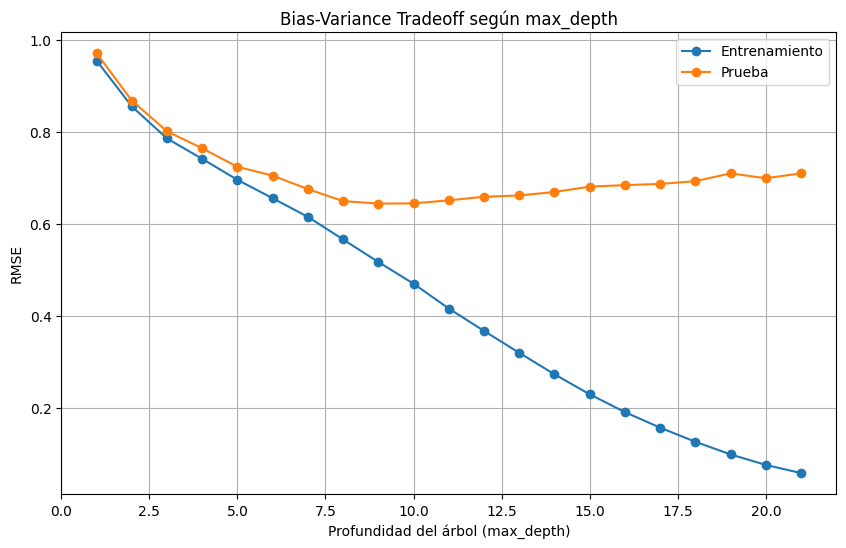

In [10]:
import matplotlib.pyplot as plt

# Lista para guardar resultados
profundidades = []
rmse_train_list = []
rmse_test_list = []

# Probar profundidades de 1 a 21
for depth in range(1, 22):
    modelo = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Entrenar modelo
    modelo.fit(X_train, y_train)

    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # Calcular RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Guardar resultados
    profundidades.append(depth)
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)

# Graficar resultados
plt.figure(figsize=(10,6))

plt.plot(profundidades, rmse_train_list, marker='o', label='Entrenamiento')
plt.plot(profundidades, rmse_test_list, marker='o', label='Prueba')

plt.title("Bias-Variance Tradeoff según max_depth")
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.show()

## Resultados Bias–Variance

Se entrenaron múltiples modelos de árbol de decisión variando el parámetro max_depth desde 1 hasta 21, con el objetivo de analizar el equilibrio entre bias y variance y encontrar la profundidad óptima del modelo.

Para cada profundidad se calculó el RMSE tanto en entrenamiento como en prueba.

Se observó que, conforme aumenta la profundidad del árbol, el error de entrenamiento disminuye constantemente, ya que el modelo logra ajustarse cada vez mejor a los datos de entrenamiento.

Sin embargo, el error en prueba disminuye únicamente hasta cierta profundidad (9 o 10); posteriormente comienza a aumentar nuevamente. El punto donde el modelo generaliza mejor se encuentra aproximadamente entre max_depth = 9 y max_depth = 10, donde el RMSE de prueba alcanza su valor mínimo.

Esto representa lo siguiente:

* **Bias (subajuste) → profundidades pequeñas**

* **Variance (sobreajuste) → profundidades grandes**

**Por lo tanto, una profundidad cercana a 9 o 10 resulta más adecuada que un árbol completamente libre (max_depth=None).**

# 5. Poda del árbol

* Aplicar cost-complexity pruning (ccp_alpha)

* Evaluar distintos valores de ccp_alpha con ccp_alphas = ccp_alphas[::5]

* Analizar su efecto en el error del modelo

In [11]:
from tqdm import tqdm

100%|██████████| 140/140 [00:25<00:00,  5.44it/s]


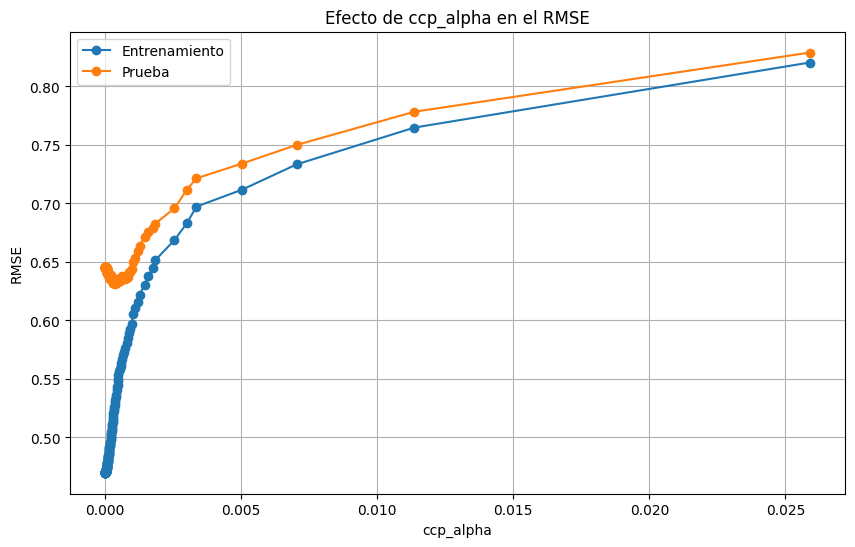

In [12]:
# Obtener ruta de poda (cost-complexity pruning path)
path = DecisionTreeRegressor(max_depth=10, random_state=42).cost_complexity_pruning_path(
    X_train, y_train
)

# Extraer valores de ccp_alpha
ccp_alphas = path.ccp_alphas

# Tomar algunos valores (cada 5 posiciones)
ccp_alphas = ccp_alphas[::5]

# Listas para guardar resultados
rmse_train_alpha = []
rmse_test_alpha = []

# Evaluar distintos valores de ccp_alpha
# for alpha in ccp_alphas:
for alpha in tqdm(ccp_alphas): # librería para mostrar barra de progreso
    modelo_poda = DecisionTreeRegressor(
        max_depth=10,
        random_state=42,
        ccp_alpha=alpha
    )

    # Entrenar modelo
    modelo_poda.fit(X_train, y_train)

    # Predicciones
    y_train_pred = modelo_poda.predict(X_train)
    y_test_pred = modelo_poda.predict(X_test)

    # Calcular RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Guardar resultados
    rmse_train_alpha.append(rmse_train)
    rmse_test_alpha.append(rmse_test)

# Graficar resultados
plt.figure(figsize=(10,6))

plt.plot(ccp_alphas, rmse_train_alpha, marker='o', label='Entrenamiento')
plt.plot(ccp_alphas, rmse_test_alpha, marker='o', label='Prueba')

plt.title("Efecto de ccp_alpha en el RMSE")
plt.xlabel("ccp_alpha")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Encontrar el mejor alpha

best_idx = np.argmin(rmse_test_alpha)
best_alpha = ccp_alphas[best_idx]

print("Mejor ccp_alpha:", best_alpha)

Mejor ccp_alpha: 0.00033998267401896907


In [15]:
# reentrenar el modelo con el mejor aplha, esto también para sacar las variables más relevantes
modelo_final = DecisionTreeRegressor(
    max_depth=10,
    random_state=42,
    ccp_alpha=best_alpha
)

modelo_final.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=np.float64(0.00033998267401896907),
                      max_depth=10, random_state=42)

# 6. Interpretación de resultados
## ¿El modelo base presenta sobreajuste? Explique

Sí, el modelo base presenta un claro caso de sobreajuste (overfitting).

El árbol fue entrenado sin restricciones de profundidad (max_depth=None), lo que permitió que creciera hasta ajustarse completamente a los datos de entrenamiento.

Los resultados obtenidos fueron:

RMSE entrenamiento: 0.0000
RMSE prueba: 0.7037
R² entrenamiento: 1.0000
R² prueba: 0.6221

Un R² igual a 1 y un RMSE igual a 0 en entrenamiento indican que el modelo memorizó perfectamente los datos de entrenamiento. Sin embargo, en prueba el error aumenta considerablemente y el R² disminuye, lo que demuestra que el modelo no generaliza adecuadamente sobre datos nuevos.

Por ello, se concluye que existe sobreajuste.

## ¿Cómo afecta la profundidad del árbol al error?

La profundidad del árbol tiene un impacto directo en el equilibrio entre bias y variance.

Cuando la profundidad es pequeña (max_depth bajo), el modelo es demasiado simple y no logra capturar correctamente los patrones de los datos, generando subajuste (underfitting) y errores altos tanto en entrenamiento como en prueba.

A medida que aumenta la profundidad, el error de entrenamiento disminuye constantemente, ya que el modelo se ajusta mejor a los datos.

Sin embargo, el error de prueba solo mejora hasta cierto punto. En este caso, el mejor desempeño se observó aproximadamente entre max_depth = 9 y max_depth = 10, donde el RMSE de prueba alcanzó su valor mínimo.

Después de ese punto, seguir aumentando la profundidad provoca sobreajuste, ya que el modelo comienza a memorizar los datos de entrenamiento y pierde capacidad de generalización.

## ¿Qué efecto tiene la poda en el modelo?

La poda mediante ccp_alpha reduce la complejidad del árbol eliminando ramas poco relevantes.

Cuando ccp_alpha es muy pequeño, el árbol conserva una estructura más compleja y puede presentar sobreajuste.

Al aumentar ligeramente ccp_alpha, el RMSE de prueba disminuye, lo que indica una mejora en la generalización del modelo.

Sin embargo, cuando la poda es excesiva (ccp_alpha grande), tanto el error de entrenamiento como el de prueba aumentan, ya que el modelo se vuelve demasiado simple y aparece subajuste.

Por lo tanto, la poda ayuda a encontrar un mejor equilibrio entre complejidad y capacidad predictiva.

## ¿Cuál configuración produce el mejor desempeño?

La mejor configuración se obtuvo con un árbol de profundidad aproximada entre max_depth = 9 y max_depth = 10, complementado con un valor pequeño de ccp_alpha, donde el RMSE de prueba alcanzó su valor mínimo.

Esta configuración permitió evitar el sobreajuste del modelo base sin caer en subajuste, logrando el mejor equilibrio entre ajuste y generalización.

En comparación con el árbol completamente libre (max_depth=None), esta versión controlada produjo un mejor desempeño sobre datos no vistos.

## ¿Qué variables son más relevantes según el modelo?

In [16]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_final.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

print(importancias)

     Variable  Importancia
0      MedInc     0.637461
5    AveOccup     0.130953
6    Latitude     0.074829
7   Longitude     0.059243
1    HouseAge     0.043153
2    AveRooms     0.034583
4  Population     0.012040
3   AveBedrms     0.007737


Las variables más relevantes según el modelo fueron aquellas con mayor valor en feature_importances_. Se observa que MedInc (ingreso medio) es, por mucho, la variable más influyente, concentrando aproximadamente el 64% de la importancia total del modelo.

En segundo lugar, AveOccup también presenta una contribución relevante, seguida por las variables geográficas Latitude y Longitude, lo que indica que tanto las condiciones socioeconómicas como la ubicación tienen un papel importante en la determinación del valor de las viviendas.

Por otro lado, variables como Population y AveBedrms presentan una importancia muy baja, lo que sugiere que tienen poca influencia en la predicción del modelo.

En general, el modelo se apoya principalmente en factores económicos y de ubicación, más que en características físicas de las viviendas.